# **Example usage of `MultiTreatmentUnivariateEncoding`**

This example shows how to generate a model and compute statistics on both numerical and categorical variables.

# 1. Import Libraries and Load Data
Start by importing the required libraries and loading your dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import kuplift
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("data.csv")

# Check the initial data types
print("Initial data types:")
print(df.dtypes)

Initial data types:
VAR1          float64
VAR2              str
VAR3          float64
VAR4          float64
TRAITEMENT        str
CIBLE           int64
dtype: object


# 2. Data Preparation
Convert relevant columns to categorical types for better encoding. Check the data to ensure correctness.

In [2]:
# Convert categorical columns to object dtype if not detected
## Disabled because these are properly detected as categorial.
# df = df.astype({"VAR2": object, "CIBLE": object})

# Verify the conversion
print("Data types after conversion:")
print(df.dtypes)

# Display the first few rows
df.head(10)

Data types after conversion:
VAR1          float64
VAR2              str
VAR3          float64
VAR4          float64
TRAITEMENT        str
CIBLE           int64
dtype: object


,VAR1,VAR2,VAR3,VAR4,TRAITEMENT,CIBLE
0,0.015094,C,0.366305,0.805962,T0,0
1,0.565127,A,0.650894,0.670533,T0,0
2,0.400678,A,0.202089,0.106898,T0,1
3,0.520210,B,NaN,0.643838,T0,0
4,0.120742,B,0.819230,0.374633,T0,0
5,0.914623,C,0.985132,0.021801,T0,0
6,0.988767,B,0.375908,0.371750,T0,0
7,0.333302,B,0.136996,0.409181,T0,0
8,0.781956,B,0.335278,0.498639,T0,0
9,0.190564,B,0.048218,0.967819,T0,0


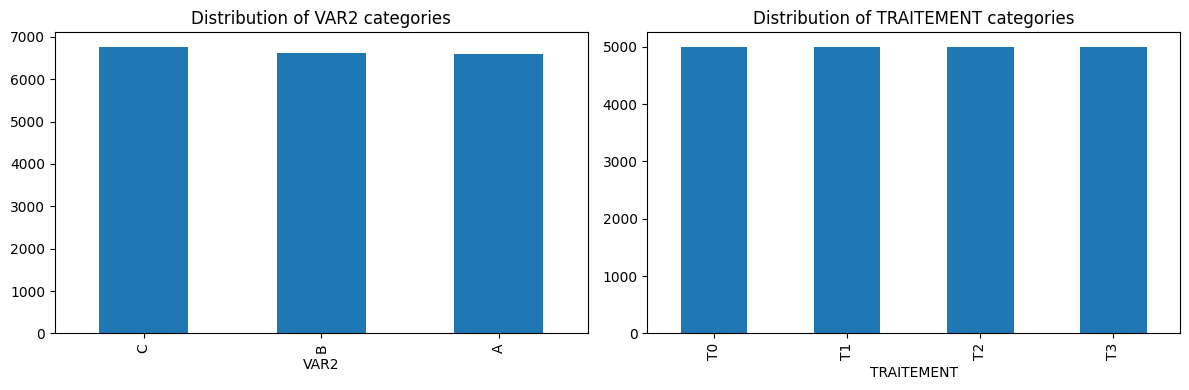

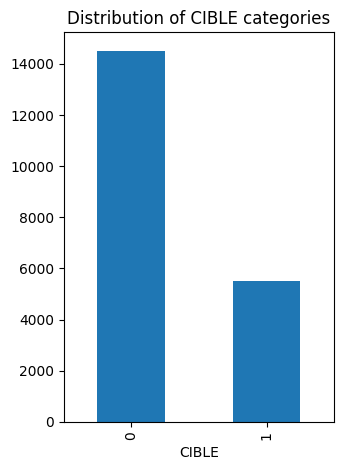

In [3]:
# Example: Plot category counts
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['VAR2'].value_counts().plot(kind='bar')
plt.title('Distribution of VAR2 categories')

plt.subplot(1, 2, 2)
df['TRAITEMENT'].value_counts().plot(kind='bar')
plt.title('Distribution of TRAITEMENT categories')
plt.tight_layout()
plt.show()


plt.subplot(1, 2, 2)
df['CIBLE'].value_counts().plot(kind='bar')
plt.title('Distribution of CIBLE categories')
plt.tight_layout()
plt.show()


# 3. Univariate Encoding
Discretize variables to improve model interpretability and performance.

In [4]:
# Initialize the encoder
ue = kuplift.multi_treatment_univariate_encoding.MultiTreatmentUnivariateEncoding()

# Fit and transform the data
# Assuming 'TRAITEMENT' is the treatment column, 'CIBLE' is the outcome
encoded_df = ue.fit_transform(df[df.columns[:-2]], df["TRAITEMENT"], df["CIBLE"])
# just for fit 
# ue.fit(df[df.columns[:-2]], df["TRAITEMENT"], df["CIBLE"])

# Show the encoded data
encoded_df.head()

,VAR1,VAR2,VAR3
0,0,0,2
1,2,2,2
2,1,2,2
3,2,1,0
4,0,1,3


In [5]:
# Retrieve all variable levels
levels = ue.get_levels()

# Display levels
print("Variable levels after encoding:")
for var_name, level in levels:
    print(f"{var_name}: {level}")

Variable levels after encoding:
VAR1: 0.0877854
VAR2: 0.0843636
VAR3: 0.0335084
VAR4: 0.0


VAR1: 3
VAR2: 3
VAR3: 4
VAR4: 1


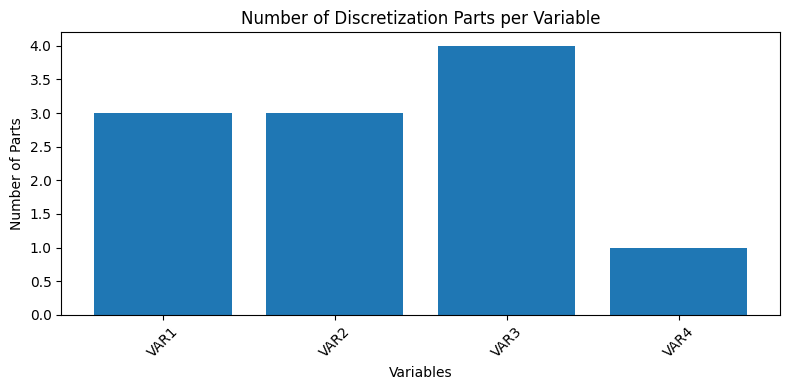

In [6]:
# List of input variables
variables = ue.input_variables

# Count parts for each variable, considering no partition if level=0
parts_per_variable = {var: len(list(ue.get_partition(var))) if var in ue.informative_input_variables else 1 for var in variables}

# Display the number of parts per variable
for var, count in parts_per_variable.items():
    print(f"{var}: {count}")

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(parts_per_variable.keys(), parts_per_variable.values())
plt.xlabel('Variables')
plt.ylabel('Number of Parts')
plt.title('Number of Discretization Parts per Variable')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [7]:
levels = ue.get_levels()

if not levels:
    # Pas de niveaux, donc pas de partition
    print("No levels (no partition for this variable).")
else:
    # Traitement normal
    # Exemple : compter le nombre de niveaux pour une variable spécifique
    variable_name = "VAR1"
    num_levels = sum(1 for v, _ in levels if v == variable_name)
    print(f"Number of levels for {variable_name}: {num_levels}")

Number of levels for VAR1: 1


# 4. Partition and Frequency Analysis
"Examine how variables are partitioned and how target outcomes distribute across segments."

In [8]:
# Get partition details for specific variables
print("Partition for VAR1:\n", ue.get_partition("VAR1"))

# Get target frequencies for VAR1
freqs_var1 = ue.get_target_frequencies("VAR1")
print("Target frequencies for VAR1:\n", freqs_var1)

# Get target probabilities for VAR1
probs_var1 = ue.get_target_probabilities("VAR1")
print("Target probabilities for VAR1:\n", probs_var1)

Partition for VAR1:
 Interval partition
    3 intervals:
      - [-inf, 0.200215[
      - [0.200215, 0.499824[
      - [0.499824, inf[
Target frequencies for VAR1:
                    Part  (0|T0)  (0|T1)  (0|T2)  (0|T3)  (1|T0)  (1|T1)  \
0      [-inf, 0.200215[     717     493     989     992     258     535   
1  [0.200215, 0.499824[    1098     649    1469     684     388     853   
2       [0.499824, inf[    2539    2470    1213    1197       0       0   

   (1|T2)  (1|T3)  
0       0       0  
1       0     797  
2    1329    1330  
Target probabilities for VAR1:
                    Part    (0|T0)    (0|T1)    (0|T2)    (0|T3)    (1|T0)  \
0      [-inf, 0.200215[  0.735385  0.479572  1.000000  1.000000  0.264615   
1  [0.200215, 0.499824[  0.738896  0.432091  1.000000  0.461850  0.261104   
2       [0.499824, inf[  1.000000  1.000000  0.477183  0.473684  0.000000   

     (1|T1)    (1|T2)    (1|T3)  
0  0.520428  0.000000  0.000000  
1  0.567909  0.000000  0.538150  
2  0.000000

In [9]:
print(ue.get_partition("VAR1"))

Interval partition
    3 intervals:
      - [-inf, 0.200215[
      - [0.200215, 0.499824[
      - [0.499824, inf[


In [10]:
print(ue.get_partition("VAR2"))

Value group partition
    3 groups ("*" indicates the default group):
        - {C}
        - {B}
      * - {A}


# 5. uplift plot for VAR1 variable
Step plot of uplift with average uplift for VAR1 variable

In [11]:
ue.get_target_frequencies("VAR1")

,Part,(0|T0),(0|T1),(0|T2),(0|T3),(1|T0),(1|T1),(1|T2),(1|T3)
0,"[-inf, 0.200215[",717,493,989,992,258,535,0,0
1,"[0.200215, 0.499824[",1098,649,1469,684,388,853,0,797
2,"[0.499824, inf[",2539,2470,1213,1197,0,0,1329,1330


In [12]:
uplift_var1 = ue.get_uplift(1, "T0", "VAR1")

In [13]:
from kuplift.helperclasses import TargetTreatmentPair as TT
freqs_var1 = ue.get_target_frequencies("VAR1")
avg_uplift_T1_T0 = freqs_var1[TT(1, "T1")].sum() / (freqs_var1[TT(1, "T1")].sum() + freqs_var1[TT(0, "T1")].sum()) - freqs_var1[TT(1, "T0")].sum() / (freqs_var1[TT(1, "T0")].sum() + freqs_var1[TT(0, "T0")].sum())

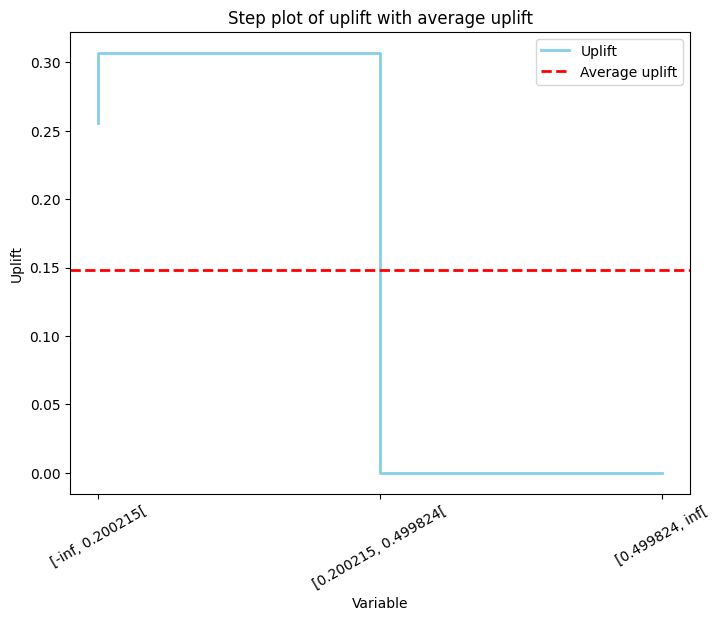

In [14]:
# Convert the 'Part' column to labels
x_labels = uplift_var1['Part'].astype(str)
x_positions = range(len(x_labels))

plt.figure(figsize=(8, 6))
plt.step(x_positions, uplift_var1['Uplift 1 T1'], color='skyblue', label='Uplift', linewidth=2)

# Add labels below each bar
plt.xticks(x_positions, x_labels, rotation=30)

# Add the reference line
plt.axhline(y=avg_uplift_T1_T0, color='red', linestyle='--', linewidth=2, label='Average uplift')

# Labels and title
plt.xlabel('Variable')
plt.ylabel('Uplift')
plt.title("Step plot of uplift with average uplift")
plt.legend()

plt.show()

# 5. Additional Variables Analysis
Compare the segmentation and uplift effects across different variables.

In [15]:
# Get partition details for VAR2
ue.get_partition("VAR2")

ValGrpPartition([ValGrp(['C']), ValGrp(['B']), ValGrp(['A'])], 2)

In [16]:
# Get target frequencies for VAR2
ue.get_target_frequencies("VAR2")

,Part,(0|T0),(0|T1),(0|T2),(0|T3),(1|T0),(1|T1),(1|T2),(1|T3)
0,{C},1721,1007,986,588,0,716,679,1074
1,{B},1615,1005,1675,1664,0,672,0,0
2,{A},1018,1600,1010,621,646,0,650,1053


In [17]:
# Get target probabilities for VAR2
ue.get_target_probabilities("VAR2")

,Part,(0|T0),(0|T1),(0|T2),(0|T3),(1|T0),(1|T1),(1|T2),(1|T3)
0,{C},1.000000,0.584446,0.592192,0.353791,0.000000,0.415554,0.407808,0.646209
1,{B},1.000000,0.599284,1.000000,1.000000,0.000000,0.400716,0.000000,0.000000
2,{A},0.611779,1.000000,0.608434,0.370968,0.388221,0.000000,0.391566,0.629032


In [18]:
# Get Uplift for VAR2 with traget modality 1 and control group T0
ue.get_uplift(1, "T0", "VAR2")

,Part,Uplift 1 T1,Uplift 1 T2,Uplift 1 T3
0,{C},0.415554,0.407808,0.646209
1,{B},0.400716,0.000000,0.000000
2,{A},-0.388221,0.003345,0.240811


In [19]:
# Get treatment groups for VAR1
ue.get_treatment_groups("VAR2")

{ValGrp(['C']): [['T1', 'T2'], ['T0'], ['T3']],
 ValGrp(['B']): [['T2', 'T3', 'T0'], ['T1']],
 ValGrp(['A']): [['T0', 'T2'], ['T3'], ['T1']]}